<a href="https://colab.research.google.com/github/veronicaagunbiade-cmyk/CodeAlpha-Data-Science-Internship/blob/main/Sales_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sales Prediction Using Python

## Project Objective

The objective of this project is to build a machine learning model capable of predicting product sales based on advertising expenditure across different media channels such as TV, Radio, and Newspaper. The project demonstrates the application of regression techniques for predictive analytics.

In [1]:
from google.colab import files

uploaded = files.upload()

Saving Advertising.csv to Advertising.csv


## Import Libraries

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

## Load Dataset

In [3]:
df = pd.read_csv('Advertising.csv')

df.head()

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [4]:
df.head()

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


## Data Exploration

In [5]:
df.shape

(200, 5)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   Radio       200 non-null    float64
 3   Newspaper   200 non-null    float64
 4   Sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


In [7]:
df.describe()

,Unnamed: 0,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,147.042500,23.264000,30.554000,14.022500
std,57.879185,85.854236,14.846809,21.778621,5.217457
min,1.000000,0.700000,0.000000,0.300000,1.600000
25%,50.750000,74.375000,9.975000,12.750000,10.375000
50%,100.500000,149.750000,22.900000,25.750000,12.900000
75%,150.250000,218.825000,36.525000,45.100000,17.400000
max,200.000000,296.400000,49.600000,114.000000,27.000000


In [8]:
df.isnull().sum()

,0
Unnamed: 0,0
TV,0
Radio,0
Newspaper,0
Sales,0


## Data Preprocessing

In [9]:
df.drop(
    'Unnamed: 0',
    axis=1,
    inplace=True
)

df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


## Exploratory Data Analysis (EDA)

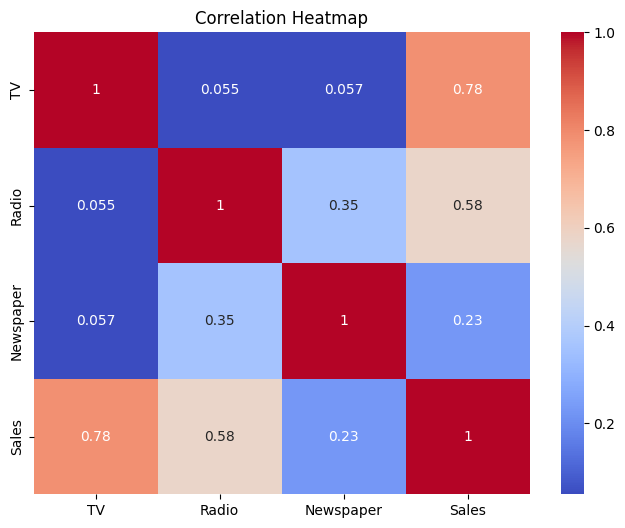

In [10]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title(
    'Correlation Heatmap'
)

plt.show()

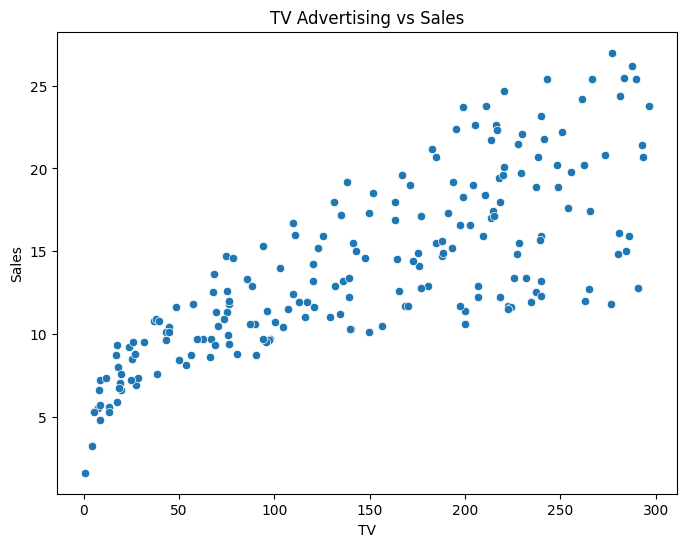

In [11]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='TV',
    y='Sales'
)

plt.title(
    'TV Advertising vs Sales'
)

plt.show()

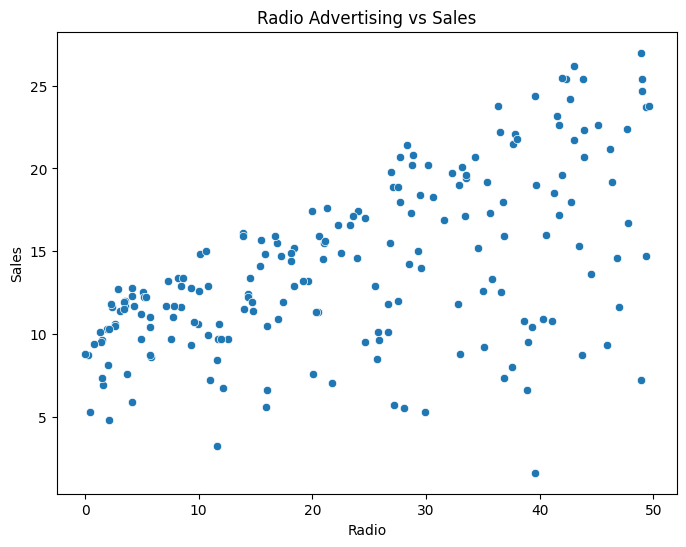

In [12]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='Radio',
    y='Sales'
)

plt.title(
    'Radio Advertising vs Sales'
)

plt.show()

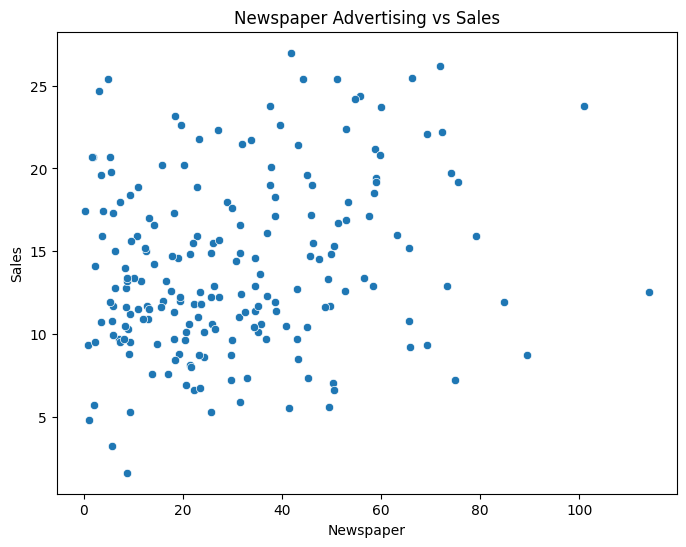

In [13]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='Newspaper',
    y='Sales'
)

plt.title(
    'Newspaper Advertising vs Sales'
)

plt.show()

## Model Training

In [14]:
X = df.drop(
    'Sales',
    axis=1
)

y = df['Sales']

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [16]:
model = LinearRegression()

model.fit(
    X_train,
    y_train
)

LinearRegression()

## Model Evaluation

In [17]:
y_pred = model.predict(X_test)

In [18]:
mae = mean_absolute_error(
    y_test,
    y_pred
)

mse = mean_squared_error(
    y_test,
    y_pred
)

r2 = r2_score(
    y_test,
    y_pred
)

print(
    "MAE =", mae
)

print(
    "MSE =", mse
)

print(
    "R² =", r2
)

MAE = 1.4607567168117603
MSE = 3.1740973539761033
R² = 0.899438024100912


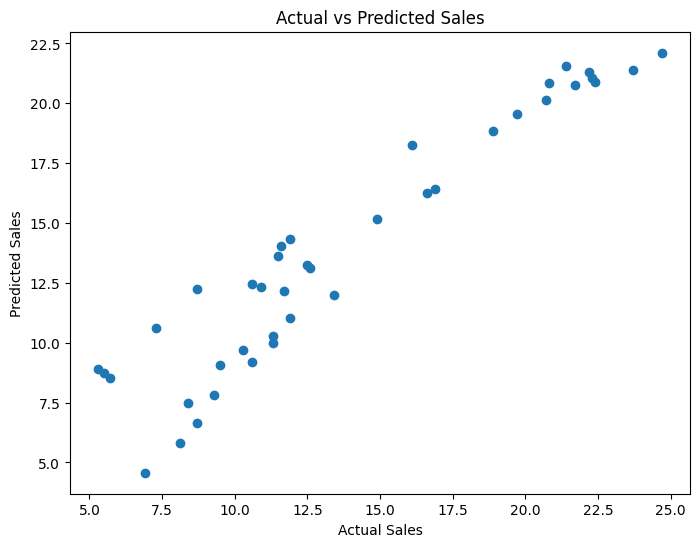

In [19]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred
)

plt.xlabel(
    'Actual Sales'
)

plt.ylabel(
    'Predicted Sales'
)

plt.title(
    'Actual vs Predicted Sales'
)

plt.show()

## Sales Prediction

In [20]:
sample = pd.DataFrame({
    'TV':[230.1],
    'Radio':[37.8],
    'Newspaper':[69.2]
})

prediction = model.predict(sample)

print(
    "Predicted Sales:",
    prediction[0]
)

Predicted Sales: 20.613971470156297


## Key Insights

### Findings

1. TV advertising expenditure showed the strongest positive relationship with sales, indicating that television marketing had the greatest influence on product performance.

2. Radio advertising also demonstrated a positive contribution to sales, although its impact was lower than that of TV advertising.

3. Newspaper advertising exhibited the weakest relationship with sales, suggesting a relatively smaller influence on overall sales performance.

4. The Linear Regression model achieved an R² score of 0.899, meaning it explained approximately 89.9% of the variation in sales.

5. The model achieved a Mean Absolute Error (MAE) of 1.461, indicating that predictions were generally close to actual sales values.

6. The analysis confirms that advertising expenditure can be effectively used to forecast product sales and support marketing decision-making.


## Conclusion

This project developed a machine learning model to predict product sales based on advertising expenditure across TV, Radio, and Newspaper channels. Through exploratory data analysis, strong relationships were identified between advertising investments and sales performance, particularly for TV advertising.

A Linear Regression model was trained and evaluated, achieving an R² score of 0.899, which indicates excellent predictive performance. The model also achieved a Mean Absolute Error (MAE) of 1.461, demonstrating its ability to generate reliable sales predictions.

The findings highlight the importance of advertising expenditure in influencing product sales and demonstrate how machine learning can be applied to support data-driven marketing strategies and business decision-making.
